# Titanic Survival Prediction

This notebook builds a machine learning workflow to predict passenger survival.

The first part focuses on creating useful features from the raw passenger data. Later sections will cover preprocessing, model training, evaluation, and model interpretation.


## 1. Setup and Data Loading

First, I import the libraries I need and load the training and test datasets.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    classification_report,
    confusion_matrix,
    brier_score_loss
)

import warnings
warnings.filterwarnings("ignore")

from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay


In [2]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

print("Training data shape:", train.shape)
print("Test data shape:", test.shape)


Training data shape: (891, 12)
Test data shape: (418, 11)


## 2. Initial Data Check

Before creating features, I checked the main columns and the data types.


In [3]:
train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 3. Feature Engineering

I will create a few features that may give the models more useful information than the raw columns alone.

The features are:

- `Title`
- `FamilySize`
- `IsAlone`
- `AgeBin`
- `FareBin`
- `Deck`
- `CabinKnown`


### Extract Title

The title is taken from the passenger's name.

Titles such as `Mr`, `Mrs`, `Miss`, and `Master` can give some information about a passenger's age and social group.


In [5]:
train["Title"] = train["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()
test["Title"] = test["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()

train["Title"].value_counts()


Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

### Create FamilySize

`FamilySize` shows how many people were travelling together in the passenger's immediate family.

The passenger is included in the total.


In [6]:
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1
test["FamilySize"] = test["SibSp"] + test["Parch"] + 1

train["FamilySize"].describe()


count    891.000000
mean       1.904602
std        1.613459
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000
Name: FamilySize, dtype: float64

### Create IsAlone

`IsAlone` shows whether a passenger was travelling alone.

A value of `1` means the passenger was alone, while `0` means they were travelling with family.


In [7]:
train["IsAlone"] = (train["FamilySize"] == 1).astype(int)
test["IsAlone"] = (test["FamilySize"] == 1).astype(int)

train["IsAlone"].value_counts()


IsAlone
1    537
0    354
Name: count, dtype: int64

### Create AgeBin

Age is grouped into a few simple categories.

I am leaving missing ages as missing for now. They will be handled later by the preprocessing pipeline.


In [8]:
age_bins = [0, 12, 18, 35, 60, np.inf]
age_labels = ["Child", "Teen", "Young Adult", "Adult", "Senior"]

train["AgeBin"] = pd.cut(
    train["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

test["AgeBin"] = pd.cut(
    test["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

train["AgeBin"].value_counts(dropna=False)


AgeBin
Young Adult    358
Adult          195
NaN            177
Teen            70
Child           69
Senior          22
Name: count, dtype: int64

### Create FareBin

Fare is grouped into four categories using the quartiles of the training data.

The bin edges come from the training data so the test data does not influence them.


In [9]:
fare_bins = train["Fare"].quantile([0, 0.25, 0.50, 0.75, 1.00]).values
fare_bins = np.unique(fare_bins)

fare_labels = ["Low", "Medium", "High", "Very High"][:len(fare_bins) - 1]

train["FareBin"] = pd.cut(
    train["Fare"],
    bins=fare_bins,
    labels=fare_labels,
    include_lowest=True
)

test["FareBin"] = pd.cut(
    test["Fare"],
    bins=fare_bins,
    labels=fare_labels,
    include_lowest=True
)

train["FareBin"].value_counts(dropna=False)


FareBin
Medium       224
Low          223
High         222
Very High    222
Name: count, dtype: int64

### Extract Deck

The first character of `Cabin` is used as the deck.

Missing cabin information is labelled as `Unknown` instead of creating a made-up deck.


In [10]:
train["Deck"] = train["Cabin"].str[0].fillna("Unknown")
test["Deck"] = test["Cabin"].str[0].fillna("Unknown")

train["Deck"].value_counts()


Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

### Create CabinKnown

`CabinKnown` shows whether cabin information is available.

This keeps the information about missing cabin records without trying to guess the missing cabin.


In [11]:
train["CabinKnown"] = train["Cabin"].notna().astype(int)
test["CabinKnown"] = test["Cabin"].notna().astype(int)

train["CabinKnown"].value_counts()


CabinKnown
0    687
1    204
Name: count, dtype: int64

### Check the New Features

I will check the new columns before moving on to the preprocessing stage.


In [12]:
new_features = [
    "Title",
    "FamilySize",
    "IsAlone",
    "AgeBin",
    "FareBin",
    "Deck",
    "CabinKnown"
]

train[new_features].head()


,Title,FamilySize,IsAlone,AgeBin,FareBin,Deck,CabinKnown
0,Mr,2,0,Young Adult,Low,Unknown,0
1,Mrs,2,0,Adult,Very High,C,1
2,Miss,1,1,Young Adult,Medium,Unknown,0
3,Mrs,2,0,Young Adult,Very High,C,1
4,Mr,1,1,Young Adult,Medium,Unknown,0


In [13]:
train[new_features].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Title       891 non-null    object  
 1   FamilySize  891 non-null    int64   
 2   IsAlone     891 non-null    int64   
 3   AgeBin      714 non-null    category
 4   FareBin     891 non-null    category
 5   Deck        891 non-null    object  
 6   CabinKnown  891 non-null    int64   
dtypes: category(2), int64(3), object(2)
memory usage: 37.1+ KB


In [14]:
train[new_features].isnull().sum()


Title           0
FamilySize      0
IsAlone         0
AgeBin        177
FareBin         0
Deck            0
CabinKnown      0
dtype: int64

## 4. Next Step

The feature engineering is now complete.

The next step is to split the training data and build a leakage-free preprocessing pipeline using `ColumnTransformer` and `Pipeline`.


## 4. Prepare the Data

The `Survived` column is the target.

I will keep the original training data for the machine learning workflow and separate the target before splitting the data.


In [15]:
X = train.drop(columns=["Survived"])
y = train["Survived"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (891, 18)
Target shape: (891,)


## 5. Train-Test Split

I will split the training data into training and validation sets.

Stratification is used so the proportion of survivors stays similar in both sets.


In [16]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Validation set:", X_valid.shape)


Training set: (712, 18)
Validation set: (179, 18)


## 6. Leakage-Free Preprocessing

The raw data contains both numerical and categorical columns.

Instead of filling missing values or creating dummy variables before the split, I will put these steps inside a `ColumnTransformer`.

This means the preprocessing is learned from the training data only.

The same preprocessing can then be used on validation or test data without fitting it again.


### Select Columns

The model will use the original numerical variables together with the new features created earlier.

`PassengerId` and `Name` are not used directly because they are identifiers or raw text fields that have already been used to create more useful features.


In [17]:
numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone",
    "CabinKnown"
]

categorical_features = [
    "Sex",
    "Embarked",
    "Title",
    "AgeBin",
    "FareBin",
    "Deck"
]

X_train[numeric_features + categorical_features].head()


,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,CabinKnown,Sex,Embarked,Title,AgeBin,FareBin,Deck
692,3,NaN,0,0,56.4958,1,1,0,male,S,Mr,NaN,Very High,Unknown
481,2,NaN,0,0,0.0000,1,1,0,male,S,Mr,NaN,Low,Unknown
527,1,NaN,0,0,221.7792,1,1,1,male,S,Mr,NaN,Very High,C
855,3,18.0,0,1,9.3500,2,0,0,female,S,Mrs,Teen,Medium,Unknown
801,2,31.0,1,1,26.2500,3,0,0,female,S,Mrs,Young Adult,High,Unknown


### Numerical Preprocessing

For numerical columns, missing values are filled with the median.

The median is calculated by the pipeline from the training data. The values are then scaled using `StandardScaler`.


In [18]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


### Categorical Preprocessing

For categorical columns, missing values are filled with the most common value.

The categories are then converted into numeric columns using one-hot encoding.

Unknown categories in validation or test data are ignored instead of causing an error.


In [19]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


### Combine the Preprocessing Steps

`ColumnTransformer` applies the correct preprocessing to each type of column.


In [20]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])


## 7. Build the Model Pipeline

The preprocessing and model are placed in one `Pipeline`.

This is important because the preprocessing is fitted as part of the model workflow rather than separately on the full dataset.


In [21]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])


## 8. Fit the Pipeline

The pipeline is fitted using the training data only.

The imputer, scaler, and encoder learn their values from `X_train`.


In [22]:
logistic_model.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 9. Check the Validation Set

The fitted pipeline can now make predictions on the validation data.

No separate imputation or encoding is needed.


In [23]:
y_pred = logistic_model.predict(X_valid)
y_prob = logistic_model.predict_proba(X_valid)[:, 1]

print("Accuracy:", round(accuracy_score(y_valid, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_valid, y_prob), 4))
print("F1 Score:", round(f1_score(y_valid, y_pred), 4))


Accuracy: 0.838
ROC-AUC: 0.8663
F1 Score: 0.7852


## 10. Preprocessing Check

The preprocessing and model are now working together in one pipeline.

The important point is that the validation data was transformed using the preprocessing fitted on the training data. It was not used to calculate the median, scaling values, or category mapping.

This gives us a leakage-free starting point for the model comparison and cross-validation steps.


In [24]:
print(logistic_model)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare',
                                                   'FamilySize', 'IsAlone',
                                                   'CabinKnown']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                     

## 11. Check the Pipeline with Cross-Validation

The preprocessing is inside the model pipeline, so it is fitted separately inside each training fold.

This is the main reason for using `Pipeline` here instead of preprocessing the full dataset first.


In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

for train_idx, valid_idx in cv.split(X, y):
    X_fold_train = X.iloc[train_idx]
    X_fold_valid = X.iloc[valid_idx]
    y_fold_train = y.iloc[train_idx]
    y_fold_valid = y.iloc[valid_idx]

    fold_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ])

    fold_model.fit(X_fold_train, y_fold_train)
    fold_pred = fold_model.predict(X_fold_valid)

    cv_scores.append(accuracy_score(y_fold_valid, fold_pred))

print("Cross-validation accuracy:", [round(score, 4) for score in cv_scores])
print("Mean accuracy:", round(np.mean(cv_scores), 4))


Cross-validation accuracy: [0.8436, 0.8371, 0.8034, 0.8315, 0.8315]
Mean accuracy: 0.8294


## 12. Next Step

The leakage-free preprocessing is now in place and has been checked with stratified cross-validation.

The next step is to train and compare several models using the same preprocessing setup.


## 12. Model Comparison

I will compare three different classification models using the same preprocessing pipeline.

The models are:

- Logistic Regression
- Random Forest
- Gradient Boosting

Using the same preprocessing setup makes the comparison fair.


In [26]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_validate


### Define the Models

Logistic Regression gives us a simple linear baseline.

Random Forest can capture non-linear relationships.

Gradient Boosting builds trees step by step and can also capture non-linear patterns.


In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}


### Stratified Cross-Validation

I will use 5-fold stratified cross-validation.

Stratification keeps the proportion of survivors similar across the folds.

The preprocessing stays inside each model pipeline, so it is fitted separately on the training portion of every fold.


In [28]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "roc_auc", "f1"],
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "F1": scores["test_f1"].mean()
    })

results_df = pd.DataFrame(results)

results_df


,Model,Accuracy,ROC-AUC,F1
0,Logistic Regression,0.829389,0.869836,0.774486
1,Random Forest,0.809171,0.866259,0.749363
2,Gradient Boosting,0.840594,0.879120,0.777098


### Compare the Results

The table below shows the mean score across the five validation folds.

I will use all three metrics instead of choosing a model from accuracy alone.


In [29]:
results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df.round(4)


,Model,Accuracy,ROC-AUC,F1
0,Gradient Boosting,0.8406,0.8791,0.7771
1,Logistic Regression,0.8294,0.8698,0.7745
2,Random Forest,0.8092,0.8663,0.7494


In [30]:
for _, row in results_df.iterrows():
    print(
        f'{row["Model"]}: '
        f'Accuracy={row["Accuracy"]:.4f}, '
        f'ROC-AUC={row["ROC-AUC"]:.4f}, '
        f'F1={row["F1"]:.4f}'
    )


Gradient Boosting: Accuracy=0.8406, ROC-AUC=0.8791, F1=0.7771
Logistic Regression: Accuracy=0.8294, ROC-AUC=0.8698, F1=0.7745
Random Forest: Accuracy=0.8092, ROC-AUC=0.8663, F1=0.7494


## 13. Initial Model Selection

The cross-validation results give us a fair baseline comparison.

For the next stage, the best candidates can be tuned using the same leakage-free preprocessing setup.

The final model should not be selected from accuracy alone. ROC-AUC and F1 will also be considered.


## 14. Hyperparameter Tuning

The first model comparison gives a useful baseline, but the models are still using mostly default settings.

The next step is to tune the main settings for each model and see whether the results improve.


### Grid Search

GridSearchCV will test a small set of parameter combinations for each model.

The preprocessing stays inside the pipeline, so the imputation and encoding are still fitted separately inside each cross-validation fold.


In [31]:
tuning_grids = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__solver": ["liblinear", "lbfgs"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 5, 10],
            "model__min_samples_split": [2, 5]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [2, 3]
        }
    }
}


In [32]:
tuned_models = {}
tuning_results = []

for name, settings in tuning_grids.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", settings["model"])
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=settings["params"],
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True
    )

    grid.fit(X_train, y_train)

    tuned_models[name] = grid.best_estimator_

    tuning_results.append({
        "Model": name,
        "Best ROC-AUC": grid.best_score_,
        "Best Parameters": grid.best_params_
    })

tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df


,Model,Best ROC-AUC,Best Parameters
0,Logistic Regression,0.870897,"{'model__C': 0.1, 'model__solver': 'liblinear'}"
1,Random Forest,0.883700,"{'model__max_depth': 10, 'model__min_samples_s..."
2,Gradient Boosting,0.891480,"{'model__learning_rate': 0.1, 'model__max_dept..."


The grid search uses ROC-AUC to find the best parameter combination for each model.

The tuned models are then checked on the same validation set using accuracy, ROC-AUC, and F1. This gives a clearer view of how they perform outside the cross-validation search.


In [33]:
tuned_validation_results = []

for name, model in tuned_models.items():

    valid_pred = model.predict(X_valid)
    valid_prob = model.predict_proba(X_valid)[:, 1]

    tuned_validation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_valid, valid_pred),
        "ROC-AUC": roc_auc_score(y_valid, valid_prob),
        "F1": f1_score(y_valid, valid_pred)
    })

tuned_validation_df = pd.DataFrame(tuned_validation_results)

tuned_validation_df.sort_values(
    by=["ROC-AUC", "F1", "Accuracy"],
    ascending=False
).reset_index(drop=True).round(4)


,Model,Accuracy,ROC-AUC,F1
0,Logistic Regression,0.8156,0.8625,0.7519
1,Gradient Boosting,0.8212,0.8424,0.7500
2,Random Forest,0.8045,0.8395,0.7287


## 15. Choosing the Final Model

The final model is not chosen from one score.

Accuracy shows how often the predictions are correct, ROC-AUC looks at how well the model separates the two classes, and F1 gives a balance between precision and recall.

The model with the strongest overall validation results will be used for the calibration check.


In [34]:
tuned_validation_df = tuned_validation_df.sort_values(
    by=["ROC-AUC", "F1", "Accuracy"],
    ascending=False
).reset_index(drop=True)

final_model_name = tuned_validation_df.loc[0, "Model"]
final_model = tuned_models[final_model_name]

print("Selected model:", final_model_name)
print(
    "Accuracy:", round(tuned_validation_df.loc[0, "Accuracy"], 4),
    "| ROC-AUC:", round(tuned_validation_df.loc[0, "ROC-AUC"], 4),
    "| F1:", round(tuned_validation_df.loc[0, "F1"], 4)
)


Selected model: Logistic Regression
Accuracy: 0.8156 | ROC-AUC: 0.8625 | F1: 0.7519


## 16. Calibration Check

The model also needs to give sensible probabilities.

A calibration check compares the predicted survival probabilities with the actual outcomes. The Brier score is included as a simple numerical check, where a lower score is better.


In [35]:
calibrated_model = CalibratedClassifierCV(
    estimator=final_model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train, y_train)

calibrated_prob = calibrated_model.predict_proba(X_valid)[:, 1]
calibrated_pred = (calibrated_prob >= 0.5).astype(int)

calibration_results = {
    "Accuracy": accuracy_score(y_valid, calibrated_pred),
    "ROC-AUC": roc_auc_score(y_valid, calibrated_prob),
    "F1": f1_score(y_valid, calibrated_pred),
    "Brier Score": brier_score_loss(y_valid, calibrated_prob)
}

pd.DataFrame([calibration_results]).round(4)


,Accuracy,ROC-AUC,F1,Brier Score
0,0.8156,0.8622,0.7519,0.1365


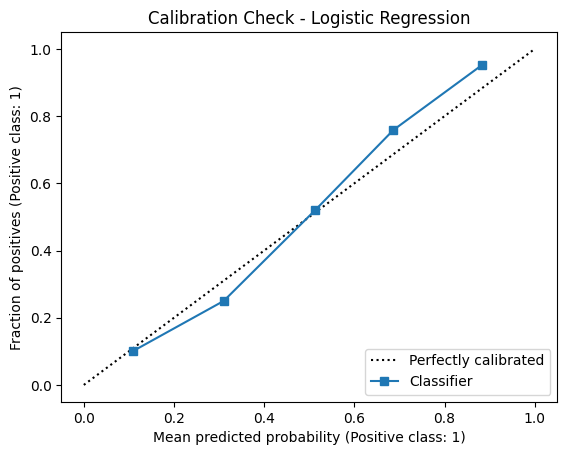

In [36]:
CalibrationDisplay.from_predictions(
    y_valid,
    calibrated_prob,
    n_bins=5
)

plt.title(f"Calibration Check - {final_model_name}")
plt.savefig("images/11_calibration_check.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## 17. Model Interpretation

The final model is now checked to see which features have the biggest effect on its predictions.

Two methods are used here:

- Permutation importance
- SHAP values

Permutation importance works with the full calibrated pipeline and shows which original input features matter most. SHAP is used with the selected Logistic Regression model so the contribution of the transformed features can be seen in more detail.

### Permutation Importance

The validation set is used to measure how much the model performance changes when one feature is shuffled.

A larger drop in ROC-AUC means the model relies more on that feature.

In [37]:
from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    calibrated_model,
    X_valid,
    y_valid,
    scoring="roc_auc",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Feature": X_valid.columns,
    "Importance": permutation_result.importances_mean,
    "Std": permutation_result.importances_std
}).sort_values("Importance", ascending=False)

permutation_df.head(10)

,Feature,Importance,Std
3,Sex,0.068584,0.021037
11,Title,0.057589,0.017838
1,Pclass,0.024262,0.008207
4,Age,0.016219,0.007511
5,SibSp,0.013775,0.007555
12,FamilySize,0.009078,0.005866
17,CabinKnown,0.005955,0.007108
8,Fare,0.003824,0.004069
14,AgeBin,0.003544,0.002090
13,IsAlone,0.001726,0.003486


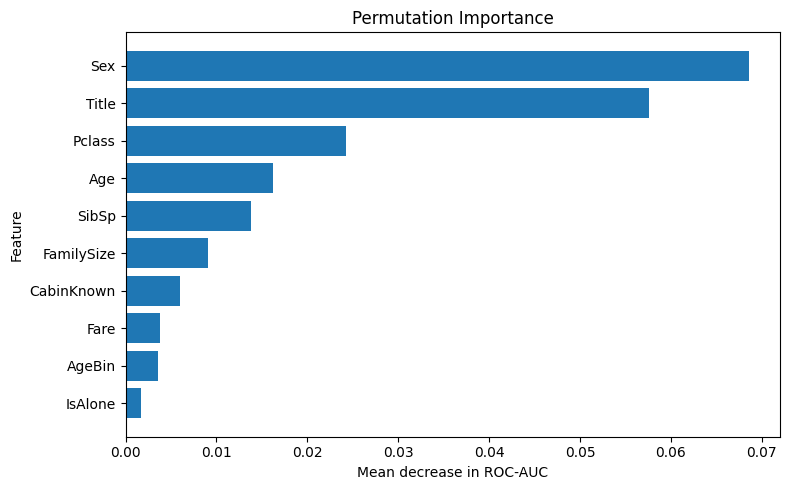

In [38]:
plt.figure(figsize=(8, 5))

top_permutation = permutation_df.head(10).sort_values("Importance")

plt.barh(
    top_permutation["Feature"],
    top_permutation["Importance"]
)

plt.title("Permutation Importance")
plt.xlabel("Mean decrease in ROC-AUC")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "images/12_permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### SHAP Values

SHAP shows how individual transformed features move the Logistic Regression prediction higher or lower.

The preprocessing is applied using the fitted pipeline from the final model. The transformed feature names are then used to show the SHAP results.

In [39]:
import shap

preprocessor = final_model.named_steps["preprocessor"]
classifier = final_model.named_steps["model"]

X_train_transformed = preprocessor.transform(X_train)
X_valid_transformed = preprocessor.transform(X_valid)

feature_names = preprocessor.get_feature_names_out()

if hasattr(X_train_transformed, "toarray"):
    X_train_shap = X_train_transformed.toarray()
    X_valid_shap = X_valid_transformed.toarray()
else:
    X_train_shap = X_train_transformed
    X_valid_shap = X_valid_transformed

explainer = shap.LinearExplainer(
    classifier,
    X_train_shap
)

shap_values = explainer.shap_values(X_valid_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

clean_feature_names = [
    name.split("__", 1)[-1]
    for name in feature_names
]

shap_importance_df = pd.DataFrame({
    "Feature": clean_feature_names,
    "Mean_Abs_SHAP": np.abs(shap_values).mean(axis=0)
}).sort_values(
    "Mean_Abs_SHAP",
    ascending=False
)

shap_importance_df.head(10)

Background dataset has 712 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=712 when initializing the masker.


,Feature,Mean_Abs_SHAP
22,Title_Mr,0.451135
0,Pclass,0.388385
8,Sex_female,0.330466
9,Sex_male,0.296631
7,CabinKnown,0.294147
1,Age,0.254765
2,SibSp,0.198642
5,FamilySize,0.173061
6,IsAlone,0.142580
23,Title_Mrs,0.116806


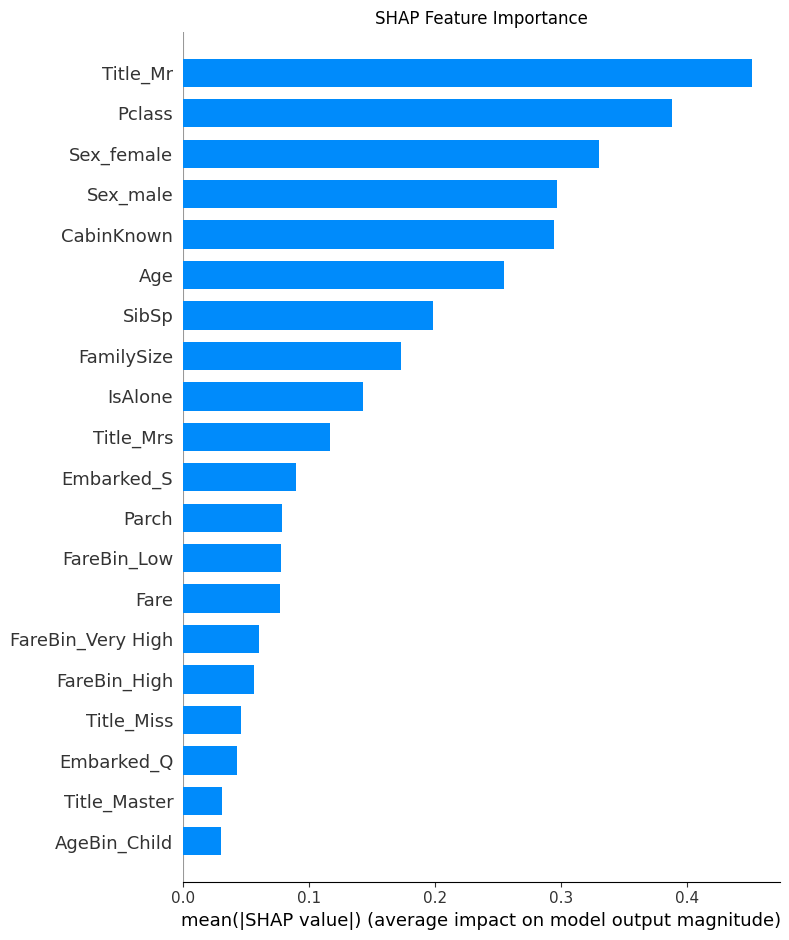

In [40]:
plt.figure(figsize=(8, 5))

shap.summary_plot(
    shap_values,
    X_valid_shap,
    feature_names=clean_feature_names,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance")
plt.tight_layout()

plt.savefig(
    "images/13_shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

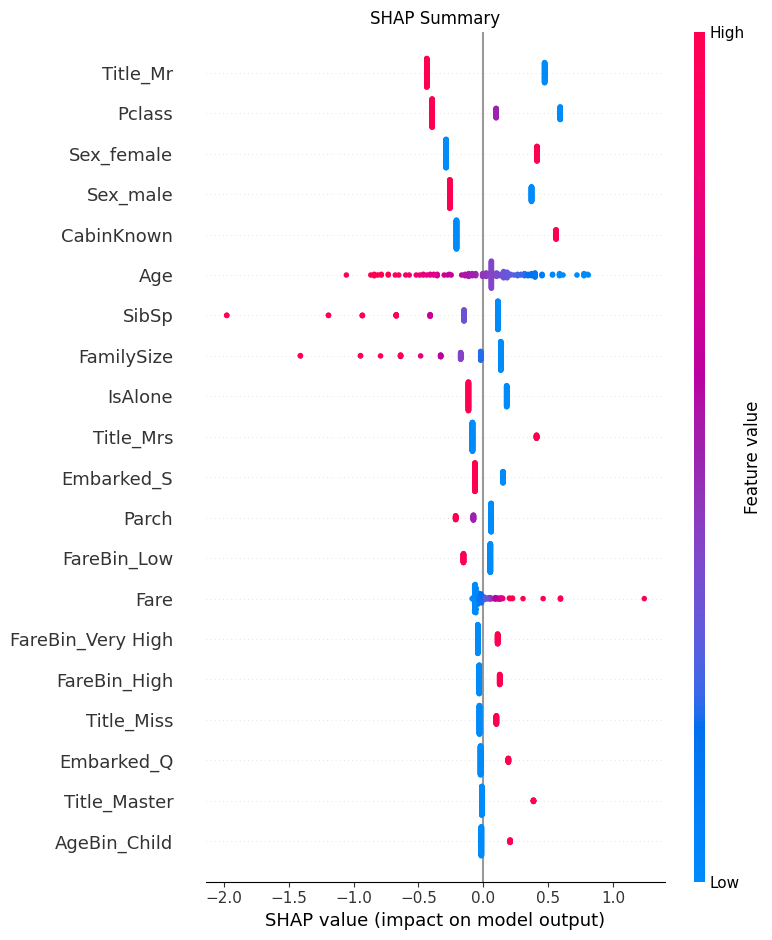

In [41]:
shap.summary_plot(
    shap_values,
    X_valid_shap,
    feature_names=clean_feature_names,
    show=False
)

plt.title("SHAP Summary")
plt.tight_layout()

plt.savefig(
    "images/14_shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Interpretation

The permutation importance table shows which original passenger features have the biggest effect on validation ROC-AUC.

The SHAP plots give a more detailed view of the transformed features and show how they contribute to the Logistic Regression predictions.

The actual feature ranking is produced when the notebook is run.

## 18. Next Step

The next step is to document the final model, its assumptions and limitations, and save the trained model pipeline as a reusable artifact.